In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random
import math

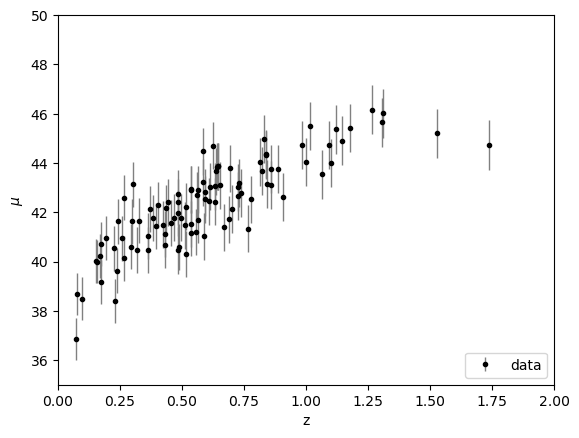

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [3]:
from astropy.cosmology import LambdaCDM

zgrid = np.linspace(0,2,1000)
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
mu_true = cosmo.distmod(zgrid)

C:\Users\balza\anaconda3copia\Lib\site-packages\astropy\cosmology\flrw\base.py:1351: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


Quick validation to choose the kernel:

In [4]:
from sklearn.model_selection import train_test_split, KFold

X = z_sample[:,np.newaxis]
y = mu_sample
dy = dmu

X_train, X_validation, ydy_train, ydy_validation = train_test_split(X, np.array([y,dy]).T, test_size=0.3, random_state=42)
y_train,dy_train = ydy_train.T
y_validation,dy_validation = ydy_validation.T

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels

kernel1 = kernels.RBF(10, (1e-2, 1e2))
kernel2 = kernels.RBF(10, (1e-2, 1e2)) + kernels.DotProduct()
kernel3 = kernels.ConstantKernel(1.0, (1e-3, 1e3)) * kernels.RBF(10, (1e-2, 1e2))
kernel4 = kernels.ConstantKernel(1.0, (1e-3, 1e3)) * kernels.RBF(10, (1e-2, 1e2)) + kernels.WhiteKernel(1.0, (1e-3, 1e3))

gpr1 = GaussianProcessRegressor(kernel=kernel1, alpha=dy_train ** 2,random_state=0).fit(X_train, y_train)
gpr2 = GaussianProcessRegressor(kernel=kernel2, alpha=dy_train ** 2,random_state=0).fit(X_train, y_train)
gpr3 = GaussianProcessRegressor(kernel=kernel3, alpha=dy_train ** 2,random_state=0).fit(X_train, y_train)
gpr4 = GaussianProcessRegressor(kernel=kernel4, alpha=dy_train ** 2,random_state=0).fit(X_train, y_train)

print(gpr1.score(X_validation, y_validation))
print(gpr2.score(X_validation, y_validation))
print(gpr3.score(X_validation, y_validation))
print(gpr4.score(X_validation, y_validation))

0.5867226445893788
0.7389709495747111
0.7289919198254138
0.7295054380000282


In [6]:
print(gpr1.kernel_.get_params())
print(gpr2.kernel_.get_params())
print(gpr3.kernel_.get_params())
print(gpr4.kernel_.get_params())

{'length_scale': 2.724908492385716, 'length_scale_bounds': (0.01, 100.0)}
{'k1': RBF(length_scale=0.386), 'k2': DotProduct(sigma_0=40.8), 'k1__length_scale': 0.38627751585227077, 'k1__length_scale_bounds': (0.01, 100.0), 'k2__sigma_0': 40.837865538154944, 'k2__sigma_0_bounds': (1e-05, 100000.0)}
{'k1': 30.6**2, 'k2': RBF(length_scale=3.69), 'k1__constant_value': 933.9551141992562, 'k1__constant_value_bounds': (0.001, 1000.0), 'k2__length_scale': 3.6868996389436046, 'k2__length_scale_bounds': (0.01, 100.0)}
{'k1': 30.6**2 * RBF(length_scale=3.69), 'k2': WhiteKernel(noise_level=0.0612), 'k1__k1': 30.6**2, 'k1__k2': RBF(length_scale=3.69), 'k1__k1__constant_value': 935.1137008321012, 'k1__k1__constant_value_bounds': (0.001, 1000.0), 'k1__k2__length_scale': 3.693229988174044, 'k1__k2__length_scale_bounds': (0.01, 100.0), 'k2__noise_level': 0.06117015593193241, 'k2__noise_level_bounds': (0.001, 1000.0)}



Let's looks kernel2, kernel3 and kernel4:


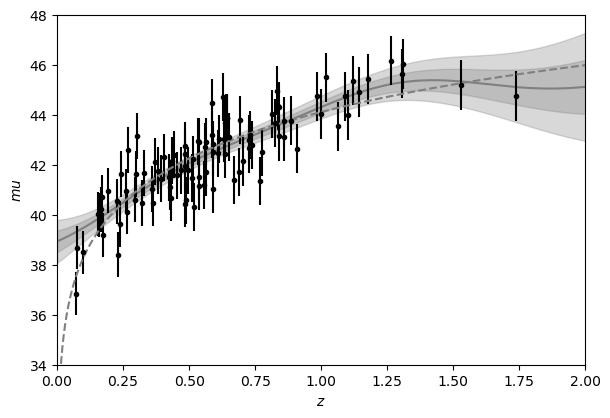

In [7]:
gpr2 = GaussianProcessRegressor(kernel=kernel2, alpha=dmu ** 2,random_state=0).fit(z_sample[:,np.newaxis], mu_sample)
mu2_pred, mu2_pred_err = gpr2.predict(zgrid[:,np.newaxis], return_std=True)

#plot
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(223)

ax.plot(zgrid, mu2_pred, '-', color='gray')
ax.fill_between(zgrid, mu2_pred - 2 * mu2_pred_err, mu2_pred + 2 * mu2_pred_err, color='gray', alpha=0.3) #2sigma
ax.fill_between(zgrid, mu2_pred - mu2_pred_err, mu2_pred + mu2_pred_err, color='gray', alpha=0.3) #onesigma
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ms=6)

plt.plot(zgrid, mu_true, '--', c='gray', label='true')

ax.set_xlabel('$z$')
ax.set_ylabel('$mu$')
ax.set_xlim(0,2)
ax.set_ylim(34,48)
plt.show()

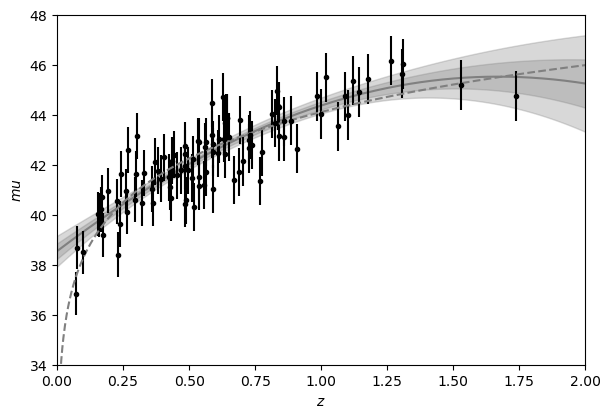

In [8]:
gpr3 = GaussianProcessRegressor(kernel=kernel3, alpha=dmu ** 2,random_state=0).fit(z_sample[:,np.newaxis], mu_sample)
mu3_pred, mu3_pred_err = gpr3.predict(zgrid[:,np.newaxis], return_std=True)

#plot
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(223)

ax.plot(zgrid, mu3_pred, '-', color='gray')
ax.fill_between(zgrid, mu3_pred - 2 * mu3_pred_err, mu3_pred + 2 * mu3_pred_err, color='gray', alpha=0.3) #2sigma
ax.fill_between(zgrid, mu3_pred - mu3_pred_err, mu3_pred + mu3_pred_err, color='gray', alpha=0.3) #1sigma
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ms=6)

plt.plot(zgrid, mu_true, '--', c='gray', label='true')

ax.set_xlabel('$z$')
ax.set_ylabel('$mu$')
ax.set_xlim(0,2)
ax.set_ylim(34,48)
plt.show()

C:\Users\balza\anaconda3copia\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


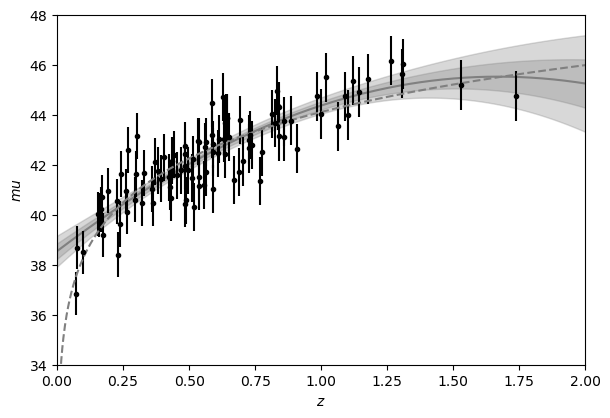

In [9]:
gpr4 = GaussianProcessRegressor(kernel=kernel4, alpha=dmu ** 2,random_state=0).fit(z_sample[:,np.newaxis], mu_sample)
mu4_pred, mu4_pred_err = gpr4.predict(zgrid[:,np.newaxis], return_std=True)

#plot
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(223)

ax.plot(zgrid, mu4_pred, '-', color='gray')
ax.fill_between(zgrid, mu4_pred - 2 * mu4_pred_err, mu4_pred + 2 * mu4_pred_err, color='gray', alpha=0.3) #2sigma
ax.fill_between(zgrid, mu4_pred - mu4_pred_err, mu4_pred + mu4_pred_err, color='gray', alpha=0.3) #1sigma
ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ms=6)

plt.plot(zgrid, mu_true, '--', c='gray', label='true')

ax.set_xlabel('$z$')
ax.set_ylabel('$mu$')
ax.set_xlim(0,2)
ax.set_ylim(34,48)
plt.show()

### Quick CV

In [10]:
from sklearn.model_selection import GridSearchCV
import itertools

K = 5 # Do 5-fold cross validation


parRange3 = [np.arange(900,940,1), np.arange(3.20, 3.60, 0.01)]
kernels3 = [kernels.ConstantKernel(a,constant_value_bounds='fixed') * kernels.RBF(b,length_scale_bounds='fixed') 
            for a, b in list(itertools.product(*parRange3))]
gpr3_cv = GaussianProcessRegressor(kernel=kernel3)

grid = GridSearchCV(gpr3_cv, {'kernel': kernels3}, cv = K, scoring='neg_mean_squared_error') # Try each degree with K-folds
grid.fit(z_sample[:, np.newaxis], mu_sample)
opt_k3 = grid.best_params_['kernel']
print(f'Optimal kernel parameters through cross validation: {opt_k3}')



#parRange4 = [np.arange(910,950,1), np.arange(3.60, 4.00, 0.01), np.arange(0.00085, 0.00125, 0.00001)]
#kernels4 = [kernels.ConstantKernel(a,constant_value_bounds='fixed') * kernels.RBF(b,length_scale_bounds='fixed') 
#            + kernels.WhiteKernel(c,noise_level_bounds='fixed') for a, b, c in list(itertools.product(*parRange4))]
#gpr4_cv = GaussianProcessRegressor(kernel=kernel4)

#grid = GridSearchCV(gpr4_cv, {'kernel': kernels4}, cv = K, scoring='neg_mean_squared_error') # Try each degree with K-folds
#grid.fit(z_sample[:, np.newaxis], mu_sample)
#opt_k4 = grid.best_params_['kernel']
#print(f'Optimal kernel parameters through cross validation: {opt_k4}')

Optimal kernel parameters through cross validation: 30**2 * RBF(length_scale=3.59)


# Cloning data

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01,1.0, 40) # Test 40 bandwidths from 0.1 to 1.0
K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(z_sample[:, np.newaxis])
bw = grid.best_params_['bandwidth']
print(bw)

0.13692307692307693


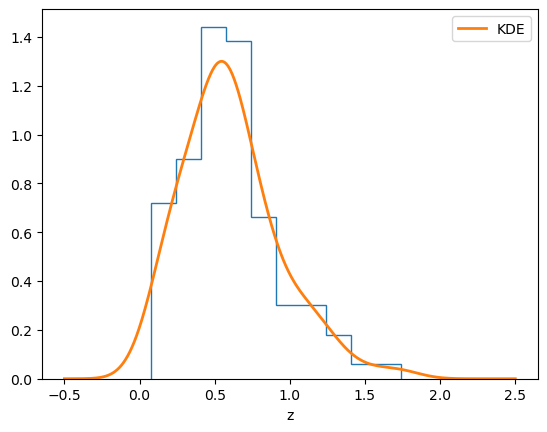

In [12]:
kde = KernelDensity(bandwidth = bw, kernel='gaussian').fit(z_sample[:, np.newaxis])
y = np.exp(kde.score_samples(np.linspace(-0.5,2.5,1000)[:,np.newaxis]))

plt.hist(z_sample, density=True, histtype='step')
plt.plot(np.linspace(-0.5,2.5,1000), y, lw=2, label='KDE')
plt.xlabel('z')
plt.legend()
plt.show()

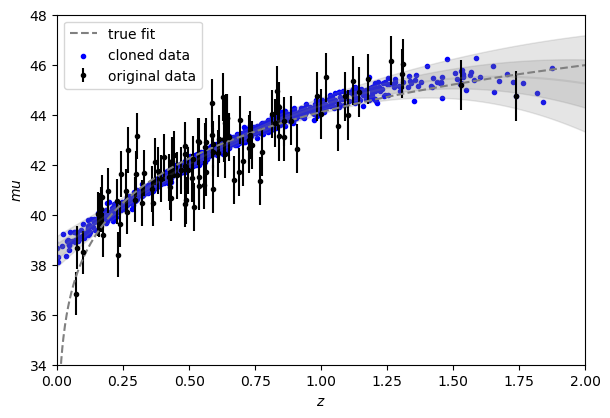

In [13]:
kernel3_best = kernels.ConstantKernel(30**2,constant_value_bounds='fixed') * kernels.RBF(3.59,length_scale_bounds='fixed')
gpr3_best = GaussianProcessRegressor(kernel=kernel3_best, alpha=dmu ** 2,random_state=0).fit(z_sample[:,np.newaxis], mu_sample)

N = 1000
new_z = kde.sample(N)

new_mu = []
for z in np.squeeze(new_z):    
    mu, sigma = gpr3_best.predict([[z]], return_std=True)
    new_mu.append(np.random.normal(loc=mu, scale=sigma))

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(223)

ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ms=6, label='original data')
ax.plot(zgrid, mu_true, '--', c='gray', label='true fit')
ax.scatter(new_z, new_mu, marker='.', c='blue', label='cloned data')
ax.plot(zgrid, mu3_pred, '-', color='gray', alpha=0.2)
ax.fill_between(zgrid, mu3_pred - 2 * mu3_pred_err, mu3_pred + 2 * mu3_pred_err, color='gray', alpha=0.2) #2sigma
ax.fill_between(zgrid, mu3_pred - mu3_pred_err, mu3_pred + mu3_pred_err, color='gray', alpha=0.2) #1sigma

ax.set_xlabel('$z$')
ax.set_ylabel('$mu$')
ax.set_xlim(0,2)
ax.set_ylim(34,48)
plt.legend()
plt.show()

# Part 3

The predicted relationship between the distance module $\mu$ and the redshift $z$ is:
$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$
Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$.

Let's try with emcee:

In [16]:
import emcee
import corner
import time

In [27]:
# parameters:
H0 = 70 #Hubble Constant
Om = 1  #Matter content of the universe

p = [H0,Om] #joint parameter space



def model(p, z):
    #from astropy.cosmology.LambdaCDM we already have the model implemented
    cosmo_model = LambdaCDM(H0=p[0], Om0=p[1], Ode0=1-p[1])
    return cosmo_model.distmod(z).value


def ln_likelihood(p,z):
    return -0.5*np.sum(((mu_sample - model(p,z))**2)/dmu**2 + np.log(2*np.pi*dmu**2)) #normalized
    #good to assume all gaussianly distributed because of the central limit theorem


def prior(p):
    prior_H0 = stats.uniform.pdf(p[0], loc=60, scale=20)
    prior_Om = stats.uniform.pdf(p[1], loc=0, scale=1)

    if prior_H0*prior_Om == 0:
        return 0
    else:
        return prior_H0*prior_Om
    

def posterior(p,z):
    return np.exp(ln_likelihood(p,z))*(prior(p))


def log_posterior(p,z):
    lp = np.log(prior(p))
    if not np.isfinite(lp):
        return -np.inf
    if not np.isfinite(ln_likelihood(p,z)):
        return -np.inf
    else:
        return ln_likelihood(p,z)+lp

In [28]:
ndim = 2         # number of parameters in the model
nwalkers = 5     # number of MCMC walkers
burn = 1000     # "burn-in" period to let chains stabilize
nsteps = 50000  # number of MCMC steps to take **for each walker**

# initialize parameters 
np.random.seed(0)
starting_guesses = np.array([H0,Om])+1e-3*np.random.random((nwalkers, ndim))

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[z_sample])
elapsed = time.time()
sampler.run_mcmc(starting_guesses, nsteps)
print(time.time()-elapsed)

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("done")

C:\Users\balza\AppData\Local\Temp\ipykernel_20608\3207781287.py:35: RuntimeWarning: divide by zero encountered in log
  lp = np.log(prior(p))
C:\Users\balza\anaconda3copia\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


482.3992614746094
done


Shape di samples: (49000, 5, 2)


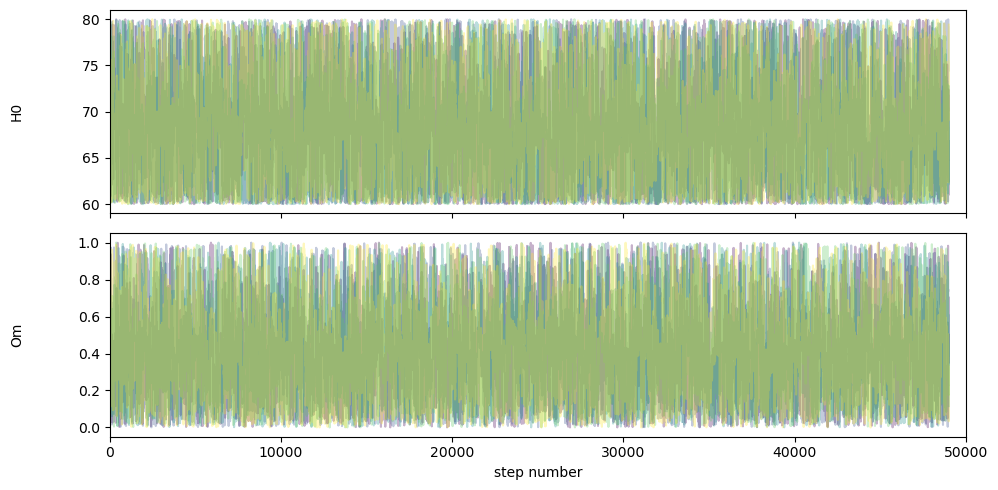

In [29]:
fig, axes = plt.subplots(2, figsize=(10, 5), sharex=True)
samples = sampler.get_chain(discard=burn)
print(f"Shape di samples: {samples.shape}")
labels = ["H0","Om"]
colors = plt.cm.viridis(np.linspace(0, 1, nwalkers))

for i in range(ndim):
    ax = axes[i]
    for j in range(nwalkers):
        ax.plot(samples[:, j, i], color=colors[j], alpha=0.3)
    ax.set_xlim(0, nsteps)
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")
plt.tight_layout()
plt.show()

In [30]:
tau = sampler.get_autocorr_time()
print(tau)

[52.03284364 51.05355044]


(4710, 2)


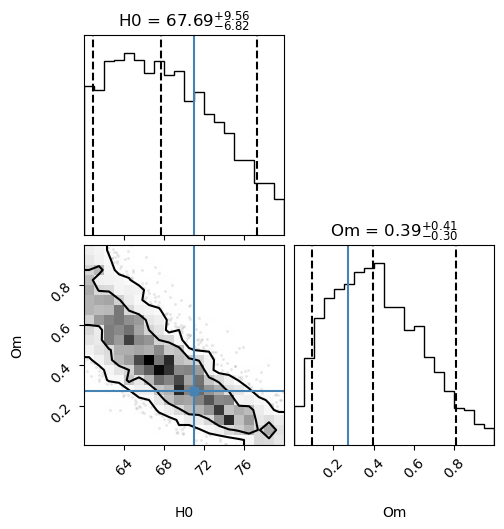

In [45]:
flat_samples = sampler.get_chain(discard=burn, thin=int(np.max(tau)), flat=True)
print(flat_samples.shape)
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95], quantiles=[0.05,0.5,0.95],
                    truths=[71,0.27], show_titles=True, title_kwargs={'fontsize':12})

C:\Users\balza\anaconda3copia\Lib\site-packages\astropy\cosmology\flrw\base.py:1351: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


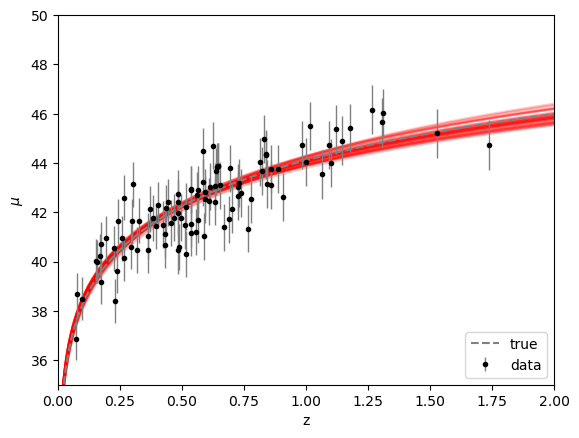

In [46]:
for H0, Om in flat_samples[::100]:
    plt.plot(zgrid, model([H0,Om], zgrid), c='red', alpha=0.2)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(zgrid, mu_true, '--', c='gray', label='true')

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()